# Variables Aleatorias

#### 01 Bernoilli y Binomial

Vamos a comenzar simulando una variable aleatoria de **Bernoulli**. Un ejemplo sencillo es el resultado de lanzar una moneda: podemos representar el resultado mediante una variable que tome el valor $1$ si obtenemos cara (éxito) y $0$ si obtenemos cruz (fracaso).

Una distribución de Bernoulli queda completamente definida por la **probabilidad de éxito**, que denotamos como $p$. En el caso de una moneda equilibrada, la probabilidad de obtener cara es $p=0.5$.

Vamos a simular ahora varios lanzamientos de esta variable y observar qué valores obtenemos.

In [ ]:
import numpy as np

# Probabilidad de éxito
p = 0.5

# Simulamos un lanzamientos
n = 1
resultados = np.random.binomial(n=1, p=p, size=n)

print(resultados)

[0]


Bernoilli es un caso particular de la binomial con un solo ensayo, si acumulamos varios lanzamientos por muestra, tenemos una distribución binomial

In [21]:
import numpy as np

# Probabilidad de éxito
p = 0.5

# Simulamos 10 lanzamientos
n = 10

resultados = np.random.binomial(
    n=1,      # Número de ensayos en cada muestra
    p=p,      # Probabilidad de éxito
    size=n    # Número de muestras
)

print(resultados)

[0 0 1 1 0 1 0 0 0 1]


En este caso trabajamos con n=1, es decir, cada muestra corresponde a un único lanzamiento de la moneda. Por tanto, cada elemento del vector resultados es una realización de una variable de Bernoulli. Al aumentar size, simplemente obtenemos más realizaciones de esta variable.

Podemos calcular para una muestra el numero de veces que hemos obtenido un exito.

In [22]:
acumulado = resultados.sum()
print(acumulado)

4


En general, no conocemos el valor de $p$. Lo que tenemos son una o varias muestras de datos y, a partir de ellas, debemos **estimar** el valor del parámetro.

Vamos a investigar cómo varía nuestra estimación de $p$ al aumentar el número de lanzamientos.

Recordemos que la **frecuencia relativa de éxitos**, que en este caso coincide con la media de una variable de Bernoulli, es un **estimador** que utilizamos para aproximar el verdadero valor de $p$.

Sin embargo, una estimación siempre lleva asociado un cierto **error de estimación**: el valor que obtenemos a partir de una muestra no tiene por qué coincidir exactamente con el valor real del parámetro.

En esta simulación conocemos el valor verdadero, $p=0.5$, por lo que podemos comparar nuestra estimación con dicho valor y cuantificar directamente el error cometido.


Por ejemplo voy a hacer 5 muestras donde lanzo la moneda 3 veces. 

In [ ]:
n_muestras = 5
n_lanzamientos = 3

resultados = []

for i in range(5): 
    resultados.append(np.random.binomial(n=1,p=p,size=n_lanzamientos))

resultados = np.array(resultados)

print(resultados)

[[1 1 0]
 [1 0 1]
 [1 0 0]
 [1 0 0]
 [1 1 1]]


En este caso hemos generado 5 muestras independientes, cada una formada por 3 lanzamientos.

Si nuestro estimador de $p$ es la frecuencia relativa de éxitos, podemos calcular una estimación de $p$ para cada una de las muestras por separado:

In [28]:
p_estimado_muestras = resultados.mean(axis=1) 
print(p_estimado_muestras)

[0.66666667 0.66666667 0.33333333 0.33333333 1.        ]


También podemos combinar todas las observaciones y calcular una única estimación utilizando los 15 lanzamientos conjuntamente:

In [30]:
p_estimado_total = resultados.mean()

print(p_estimado_total)

0.6


Vamos a hacer un experimento a lo grande. Vamos a ir aumentando el numero de lanzamientos de 5 en 5, y realizar 100 muestras de cada uno.

In [52]:
n_muestras = 100
n_lanzamientos = np.arange(5,100,5)

In [53]:
resultados = []

for n in n_lanzamientos:

    muestras = []

    for j in range(n_muestras):

        muestra = np.random.binomial(
            n=1,
            p=p,
            size=n
        )

        muestras.append(np.array(muestra))

    resultados.append(np.array(muestras))

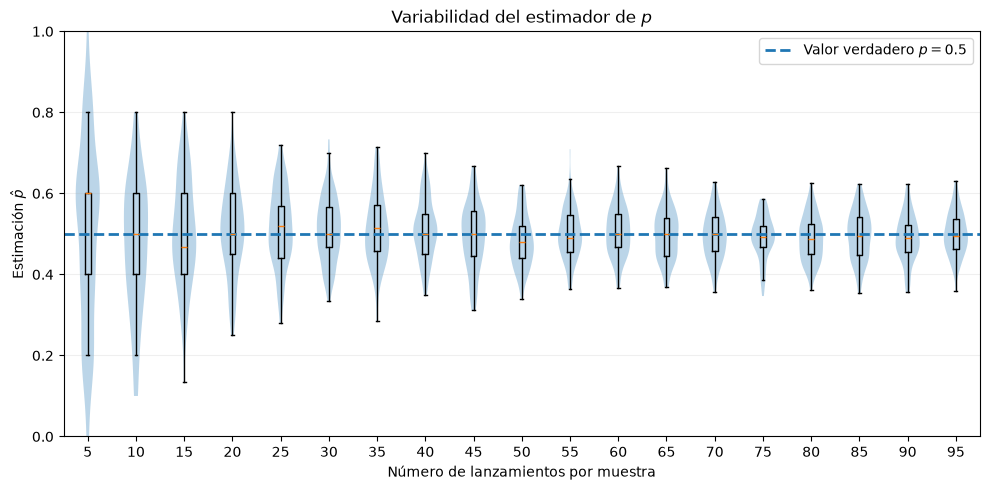

In [54]:
import numpy as np
import matplotlib.pyplot as plt

estimaciones = []

for muestras in resultados:
    
    # Media de cada muestra = estimación de p
    p_estimado = muestras.mean(axis=1)
    
    estimaciones.append(p_estimado)


# --------------------------------------------------
# Gráfico
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

parts = ax.violinplot(
    estimaciones,
    positions=np.arange(len(n_lanzamientos)),
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Añadimos el boxplot encima
ax.boxplot(
    estimaciones,
    positions=np.arange(len(n_lanzamientos)),
    widths=0.12,
    showfliers=False
)

# Valor verdadero de p
ax.axhline(
    p,
    linestyle="--",
    linewidth=2,
    label=r"Valor verdadero $p=0.5$"
)

ax.set_xticks(np.arange(len(n_lanzamientos)))
ax.set_xticklabels(n_lanzamientos)

ax.set_xlabel("Número de lanzamientos por muestra")
ax.set_ylabel(r"Estimación $\hat{p}$")
ax.set_title(r"Variabilidad del estimador de $p$")

ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.2)

ax.legend()

plt.tight_layout()
plt.show()

In [49]:
resultados[0].shape

(100, 5)